<a href="https://colab.research.google.com/github/jeevaprakash-S/24ADI006_24BAD048/blob/main/Experiment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Part A : Dataset Preparation**

In [2]:
!pip install tensorflow

In [3]:
print("Jeevaprakash 24BAD048")
import kagglehub
import tensorflow as tf

# 1. Download dataset from Kaggle
path = kagglehub.dataset_download("tongpython/cat-and-dog")
print("Dataset downloaded to:", path)

# 2. Load and preprocess images
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    path, validation_split=0.3, subset="training", seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE)

val_ds = tf.keras.utils.image_dataset_from_directory(
    path, validation_split=0.3, subset="validation", seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE)

# 3. Split validation set further into val/test
val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

Jeevaprakash 24BAD048
Using Colab cache for faster access to the 'cat-and-dog' dataset.
Dataset downloaded to: /kaggle/input/cat-and-dog
Found 10028 files belonging to 2 classes.
Using 7020 files for training.
Found 10028 files belonging to 2 classes.
Using 3008 files for validation.


# **Part B: Implementing Transfer Learning**

In [4]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# Load pre-trained ResNet-50 without the top classification layer
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# Freeze the feature extraction layers
base_model.trainable = False

# Replace the final classification layer for our dataset's classes
num_classes = 2   # change to match your dataset
inputs = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.applications.resnet50.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)
model = models.Model(inputs, outputs)

# Compile the model
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 2)         │      4,098 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

## **Part C: Model Training and Performance Evaluation**

Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 67s 184ms/step - accuracy: 0.7472 - loss: 0.6346 - val_accuracy: 0.7793 - val_loss: 0.5468
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 24s 110ms/step - accuracy: 0.7681 - loss: 0.5786 - val_accuracy: 0.7945 - val_loss: 0.5230
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 25s 115ms/step - accuracy: 0.7679 - loss: 0.5687 - val_accuracy: 0.7852 - val_loss: 0.5336
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 29s 134ms/step - accuracy: 0.7748 - loss: 0.5460 - val_accuracy: 0.7979 - val_loss: 0.5369
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 27s 123ms/step - accuracy: 0.7702 - loss: 0.5423 - val_accuracy: 0.8012 - val_loss: 0.5530
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 26s 117ms/step - accuracy: 0.7801 - loss: 0.5304 - val_accuracy: 0.8025 - val_loss: 0.5256
Epoch 7/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 26s 119ms/step - accuracy: 0.7789 - loss: 0.5394 - val_accuracy: 0.7666 - val_loss: 0.5422
Epoch 8/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 26s 120ms/step - accuracy: 0.7781 - loss: 0

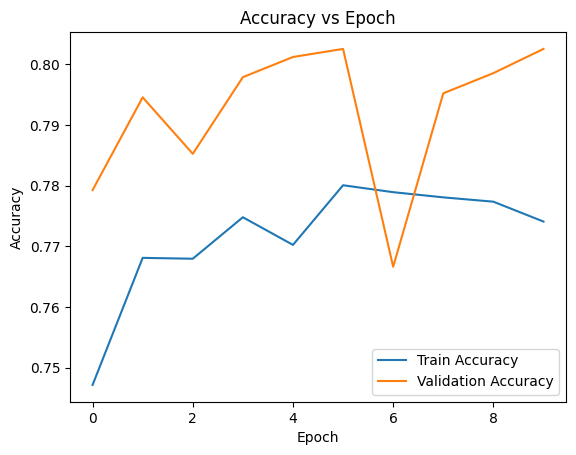

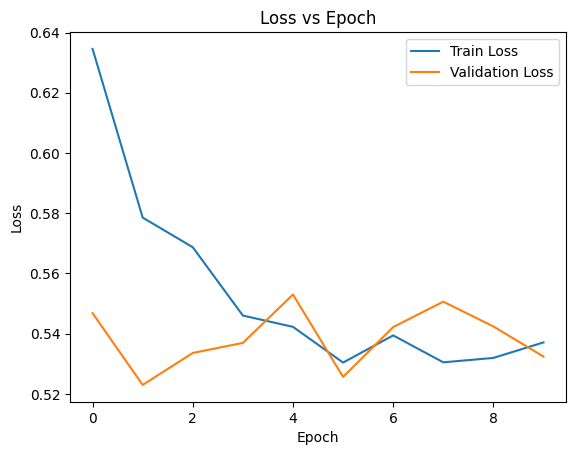

In [5]:
history = model.fit(train_ds, validation_data=val_ds, epochs=10)

test_loss, test_acc = model.evaluate(test_ds)
print("Test accuracy:", test_acc)
print("Test loss:", test_loss)

import matplotlib.pyplot as plt

# Accuracy vs Epoch
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.title("Accuracy vs Epoch")
plt.show()

# Loss vs Epoch
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.title("Loss vs Epoch")
plt.show()

## **Part D: Using Hugging Face Pre-Trained Models**

Saving Image 16-08-26 at 8.01 PM.png to Image 16-08-26 at 8.01 PM (3).png


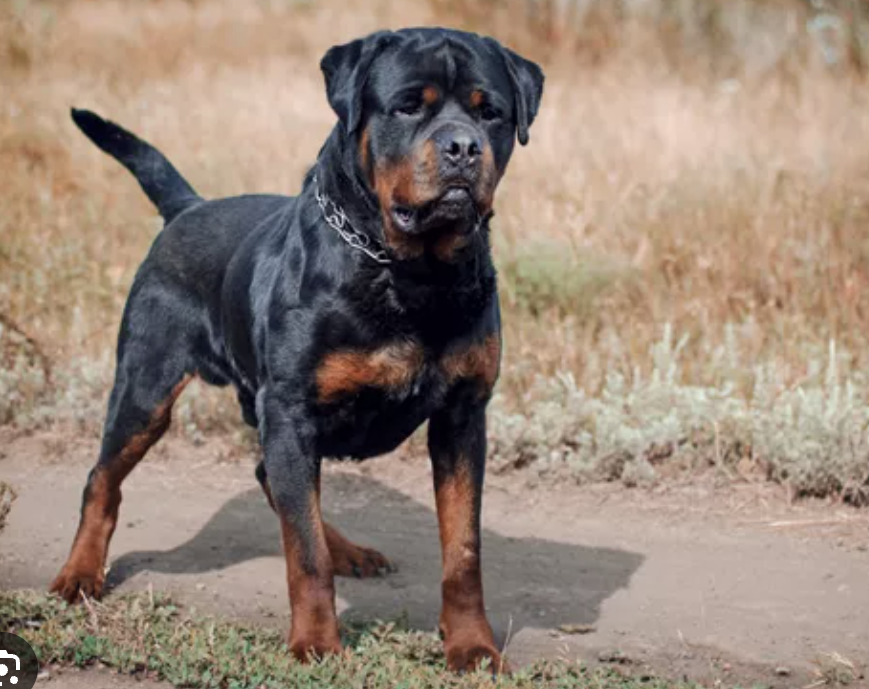

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Predicted class: Rottweiler


In [12]:
from transformers import AutoImageProcessor, AutoModelForImageClassification
import torch
from PIL import Image
from google.colab import files

uploaded = files.upload()
image = Image.open(list(uploaded.keys())[0]).convert("RGB")
display(image)

# Load a pre-trained vision model from Hugging Face (ViT)
processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224")
hf_model = AutoModelForImageClassification.from_pretrained("google/vit-base-patch16-224")

# Perform image classification on the uploaded image
inputs = processor(images=image, return_tensors="pt")
with torch.no_grad():
    logits = hf_model(**inputs).logits
predicted_class = logits.argmax(-1).item()
print("Predicted class:", hf_model.config.id2label[predicted_class])